# TP – Attaque par empoisonnement de données (Data Poisoning Attack)

Ce TP illustre une attaque par empoisonnement sur un modèle de classification
d'images (Chat / Chien / Oiseau).

Objectif :
- Comprendre comment des données malveillantes peuvent fausser un modèle IA
- Observer l'impact sur le accuracy

# 2. Import des bibliothèques

In [1]:
!pip install -q kagglehub

# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, InputLayer, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print('modules loaded')

modules loaded


# 3. Téléchargement du dataset

On télécharge le dataset depuis Kaggle et on organise les images dans /content/dataset/bird, /content/dataset/cat, /content/dataset/dog.

Prérequis : uploadez votre fichier kaggle.json depuis Kaggle → Settings → API → Create New Token.

In [2]:
from google.colab import files

print("Uploadez votre fichier kaggle.json :")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
print("Token Kaggle configuré.")

Uploadez votre fichier kaggle.json :


Saving kaggle.json to kaggle.json
Token Kaggle configuré.


In [3]:
import kagglehub

DATA_DIR = "/content/dataset"

if not os.path.exists(DATA_DIR):
    print("Téléchargement du dataset...")
    path = kagglehub.dataset_download(
        "mahmoudnoor/high-resolution-catdogbird-image-dataset-13000"
    )
    print(f"Téléchargé dans : {path}")

    os.makedirs(DATA_DIR, exist_ok=True)
    for cls in ['bird', 'cat', 'dog']:
        dst = os.path.join(DATA_DIR, cls)
        os.makedirs(dst, exist_ok=True)
        src = None
        for root, dirs, _ in os.walk(path):
            for d in dirs:
                if d.lower() == cls:
                    src = os.path.join(root, d)
                    break
            if src:
                break
        if src:
            count = 0
            for root2, _, files_list in os.walk(src):
                for fname in files_list:
                    if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                        shutil.copy2(os.path.join(root2, fname), os.path.join(dst, fname))
                        count += 1
            print(f"  {cls} : {count} images copiées")
        else:
            print(f"  Dossier '{cls}' introuvable.")
else:
    print(f"Dataset déjà présent dans {DATA_DIR}")

print("\nStructure du dataset :")
for cls in ['bird', 'cat', 'dog']:
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.exists(cls_path):
        n = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
        print(f"  {cls} : {n} images")

Téléchargement du dataset...


100%|██████████| 2.56G/2.56G [00:30<00:00, 90.0MB/s]

Extracting files...


Téléchargé dans : /root/.cache/kagglehub/datasets/mahmoudnoor/high-resolution-catdogbird-image-dataset-13000/versions/1
  bird : 4149 images copiées
  cat : 4015 images copiées
  dog : 5180 images copiées

Structure du dataset :
  bird : 4149 images
  cat : 4015 images
  dog : 5180 images


# 4. Chargement du dataset et prétraitement

In [4]:
# Define a function to load dataset images
# os.walk descend dans les sous-dossiers automatiquement (corrige le bug dataset/bird/bird/)
def recupDataset(data_dir):
    filepaths = []
    labels = []
    for cls in ['bird', 'cat', 'dog']:
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for root, _, files_list in os.walk(cls_path):
            for fname in files_list:
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    filepaths.append(os.path.join(root, fname))
                    labels.append(cls)
    return filepaths, labels

In [5]:
# Read data and store it in dataframe
filepaths, labels = recupDataset(DATA_DIR)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name='filepaths')  # contains images paths
Lseries = pd.Series(labels,    name='labels')     # contains image labels
dataset = pd.concat([Fseries, Lseries], axis=1)

print(f"Total images : {len(dataset)}")
print(dataset['labels'].value_counts())

Total images : 13344
labels
dog     5180
bird    4149
cat     4015
Name: count, dtype: int64


In [6]:
dataset.head()

,filepaths,labels
0,/content/dataset/bird/104.jpg,bird
1,/content/dataset/bird/3993.jpg,bird
2,/content/dataset/bird/3222.jpg,bird
3,/content/dataset/bird/175.jpg,bird
4,/content/dataset/bird/2396.jpg,bird


In [7]:
# Split dataframe into train, valid, and test
# train dataframe
train_ds, tmp_ds = train_test_split(dataset, train_size=0.8, shuffle=True, random_state=123)

# valid and test dataframe
valid_ds, test_ds = train_test_split(tmp_ds, train_size=0.6, shuffle=True, random_state=123)

In [8]:
#Create image data generator
# crobed image size
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Recommended : use custom function for test data batch size, else we can use normal batch size.
ts_length = len(test_ds)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

# This function which will be used in image data generator for data augmentation, it just take the image and return it again.
def scalar(img):
    return img

tr_gen = ImageDataGenerator(preprocessing_function= scalar,
                            rotation_range=40,
                            width_shift_range=0.2,
                            height_shift_range=0.2,
                            brightness_range=[0.4,0.6],
                            zoom_range=0.3,
                            horizontal_flip=True,
                            vertical_flip=True)

ts_gen = ImageDataGenerator(preprocessing_function= scalar,
                            rotation_range=40,
                            width_shift_range=0.2,
                            height_shift_range=0.2,
                            brightness_range=[0.4,0.6],
                            zoom_range=0.3,
                            horizontal_flip=True,
                            vertical_flip=True)

train_gen = tr_gen.flow_from_dataframe( train_ds, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_ds, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

# Note: we will use custom test_batch_size, and make shuffle= false
test_gen = ts_gen.flow_from_dataframe( test_ds, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)


Found 10675 validated image filenames belonging to 3 classes.
Found 1601 validated image filenames belonging to 3 classes.
Found 1068 validated image filenames belonging to 3 classes.


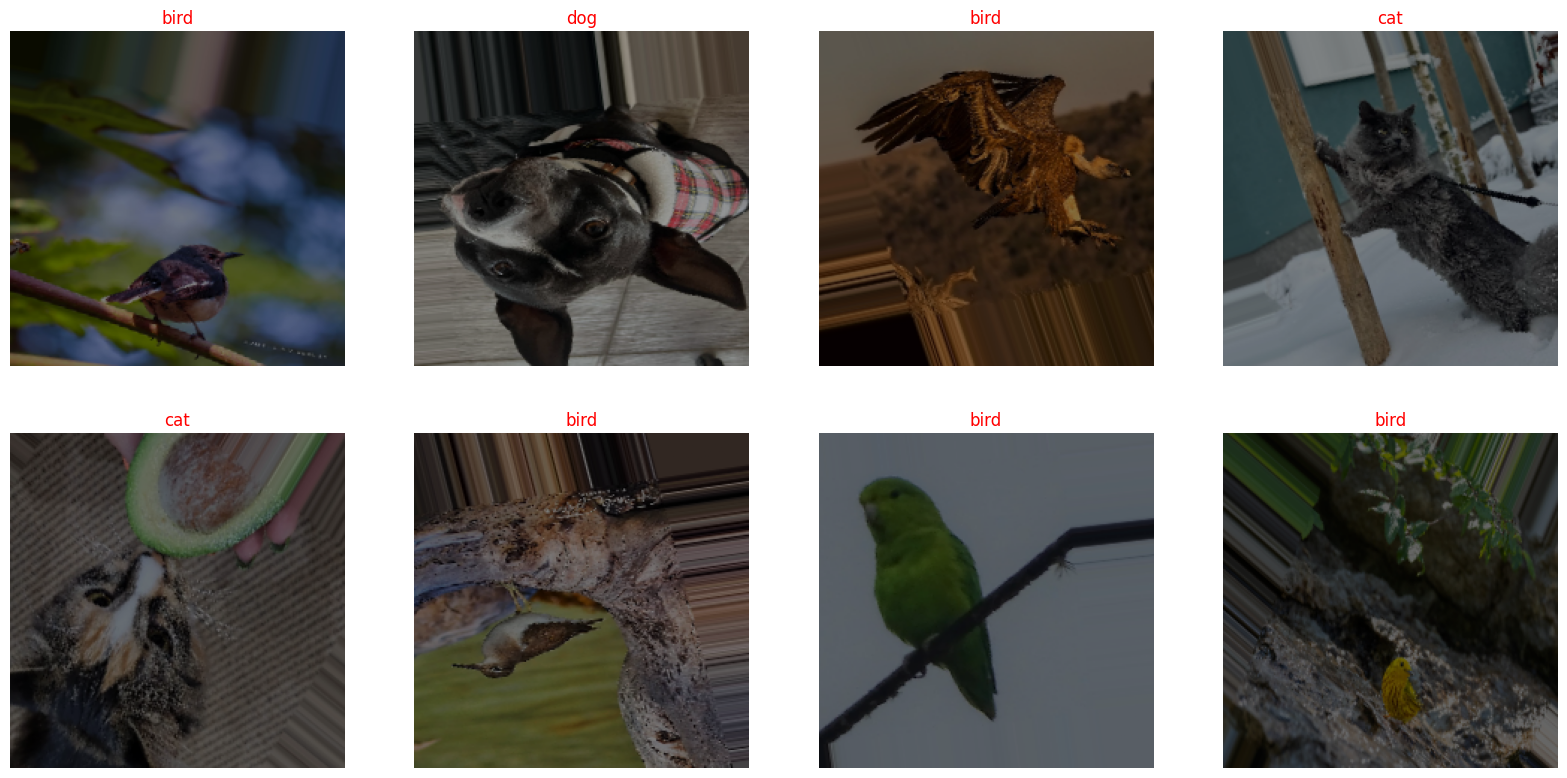

In [12]:
#Show sample from train data
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(8):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'red', fontsize= 12)
    plt.axis('off')
plt.show()

# 5. Modèle CNN

In [13]:
### Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

EfficientNetB0_model= tf.keras.applications.EfficientNetB0(include_top= False,
                                                                        weights= "imagenet",
                                                                        input_shape= img_shape,
                                                                        pooling= 'max')
EfficientNetB0_model.trainable = True

model = Sequential([
    EfficientNetB0_model,
    Dense(132, activation= 'relu'),
    Dense(64, activation= 'relu'),
    Dense(3, activation= 'softmax')
])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 132)            │       169,092 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,227,370 (16.13 MB)

 Trainable params: 4,185,347 (15.97 MB)

 Non-trainable params: 42,023 (164.16 KB)

# 6. Entraînement SANS attaque (référence)

In [14]:
os.makedirs('/content/saved_models', exist_ok=True)

adam = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=["accuracy"])

batch_size = 32
epochs = 5
history = model.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen,
                    validation_steps= None, shuffle= True)

Epoch 1/5
668/668 ━━━━━━━━━━━━━━━━━━━━ 571s 741ms/step - accuracy: 0.7809 - loss: 0.7774 - val_accuracy: 0.8613 - val_loss: 0.3685
Epoch 2/5
668/668 ━━━━━━━━━━━━━━━━━━━━ 410s 614ms/step - accuracy: 0.8830 - loss: 0.3115 - val_accuracy: 0.8020 - val_loss: 0.6375
Epoch 3/5
668/668 ━━━━━━━━━━━━━━━━━━━━ 445s 666ms/step - accuracy: 0.8893 - loss: 0.3120 - val_accuracy: 0.8963 - val_loss: 0.2925
Epoch 4/5
668/668 ━━━━━━━━━━━━━━━━━━━━ 464s 695ms/step - accuracy: 0.9022 - loss: 0.2632 - val_accuracy: 0.9076 - val_loss: 0.2582
Epoch 5/5
668/668 ━━━━━━━━━━━━━━━━━━━━ 458s 685ms/step - accuracy: 0.9076 - loss: 0.2544 - val_accuracy: 0.9107 - val_loss: 0.2632


In [15]:
ts_length = len(test_gen)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

89/89 ━━━━━━━━━━━━━━━━━━━━ 52s 583ms/step - accuracy: 0.9188 - loss: 0.2082
89/89 ━━━━━━━━━━━━━━━━━━━━ 51s 572ms/step - accuracy: 0.8911 - loss: 0.3104
89/89 ━━━━━━━━━━━━━━━━━━━━ 50s 430ms/step - accuracy: 0.9045 - loss: 0.2642
Train Loss:  0.24357782304286957
Train Accuracy:  0.908707857131958
--------------------
Validation Loss:  0.264834463596344
Validation Accuracy:  0.9016854166984558
--------------------
Test Loss:  0.265841543674469
Test Accuracy:  0.8951311111450195


# 7. Test du Modèle (normal)

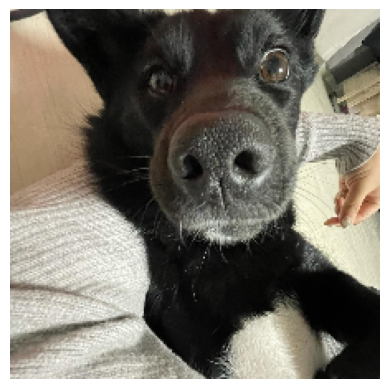

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Animal prédit : dog avec une probabilité de : 82.01%


In [16]:
import keras.utils as image
def load_image(image_path, show=True):

    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # BON preprocess pour EfficientNetB0
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)

    if show:
        plt.imshow(img)
        plt.axis('off')
        plt.show()

    return img_array


def get_label_probabilite(pred):
    g_dict = test_gen.class_indices
    classes = list(g_dict.keys())
    index = np.argmax(pred)
    label = classes[index]
    prob = pred[0][index]
    return label, prob


# Test sur une image du jeu de test
image_path = test_ds['filepaths'].iloc[0]
new_image  = load_image(image_path)
prediction = model.predict(new_image)
label, probabilite = get_label_probabilite(prediction)
print(f"Animal prédit : {label} avec une probabilité de : {probabilite*100:.2f}%")

# 8. Attaque par empoisonnement des données

Principe

On change volontairement les labels de certaines images :

* Des chats sont étiquetés comme chiens

* Des oiseaux sont étiquetés comme chats

In [17]:
# Générateur empoisonné
def poisoned_generator(generator, poison_rate=0.2):
    while True:
        images, labels = next(generator)
        num_poison = int(poison_rate * len(labels))

        for i in range(num_poison):
            labels[i] = np.roll(labels[i], 1)

        yield images, labels

# 9. Réentraînement AVEC données empoisonnées

In [18]:
poisoned_gen = poisoned_generator(train_gen, poison_rate=0.3)

model_poisoned = tf.keras.models.clone_model(model)

#adam = keras.optimizers.Adam(learning_rate=0.001)#optimizer
#model_poisoned.compile(loss='categorical_crossentropy', optimizer=adam, metrics=["accuracy"])

steps_per_epoch = train_gen.samples // train_gen.batch_size
validation_steps = valid_gen.samples // valid_gen.batch_size
#training the model
batch_size = 32   # set batch size for training
epochs = 5   # number of all epochs in training

history_poisoned = model_poisoned.fit(
    x=poisoned_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=valid_gen,
    validation_steps=validation_steps,
    verbose=1
)

Epoch 1/5
667/667 ━━━━━━━━━━━━━━━━━━━━ 540s 710ms/step - accuracy: 0.3490 - loss: 1.2716 - val_accuracy: 0.3819 - val_loss: 1.0920
Epoch 2/5
667/667 ━━━━━━━━━━━━━━━━━━━━ 412s 618ms/step - accuracy: 0.3664 - loss: 1.0979 - val_accuracy: 0.4444 - val_loss: 1.0469
Epoch 3/5
667/667 ━━━━━━━━━━━━━━━━━━━━ 410s 615ms/step - accuracy: 0.4353 - loss: 1.0607 - val_accuracy: 0.4725 - val_loss: 1.0852
Epoch 4/5
667/667 ━━━━━━━━━━━━━━━━━━━━ 430s 646ms/step - accuracy: 0.4544 - loss: 1.0539 - val_accuracy: 0.4869 - val_loss: 1.0489
Epoch 5/5
667/667 ━━━━━━━━━━━━━━━━━━━━ 442s 663ms/step - accuracy: 0.4495 - loss: 1.0496 - val_accuracy: 0.4750 - val_loss: 1.0454


In [19]:
# Evaluation des performances du modèle empoisonné
ts_length = len(test_gen)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model_poisoned.evaluate(train_gen, steps=test_steps, verbose=1)
valid_score = model_poisoned.evaluate(valid_gen, steps=test_steps, verbose=1)
test_score  = model_poisoned.evaluate(test_gen,  steps=test_steps, verbose=1)

print("Train Loss: ",      train_score[0])
print("Train Accuracy: ",  train_score[1])
print('-' * 20)
print("Validation Loss: ",     valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ",      test_score[0])
print("Test Accuracy: ",  test_score[1])

89/89 ━━━━━━━━━━━━━━━━━━━━ 54s 603ms/step - accuracy: 0.4490 - loss: 1.0460
89/89 ━━━━━━━━━━━━━━━━━━━━ 54s 608ms/step - accuracy: 0.4885 - loss: 1.0034
89/89 ━━━━━━━━━━━━━━━━━━━━ 46s 461ms/step - accuracy: 0.5018 - loss: 1.0489
Train Loss:  1.0312950611114502
Train Accuracy:  0.47542133927345276
--------------------
Validation Loss:  1.0355778932571411
Validation Accuracy:  0.4747191071510315
--------------------
Test Loss:  1.0477890968322754
Test Accuracy:  0.48689138889312744


# 10. Comparaison des performances

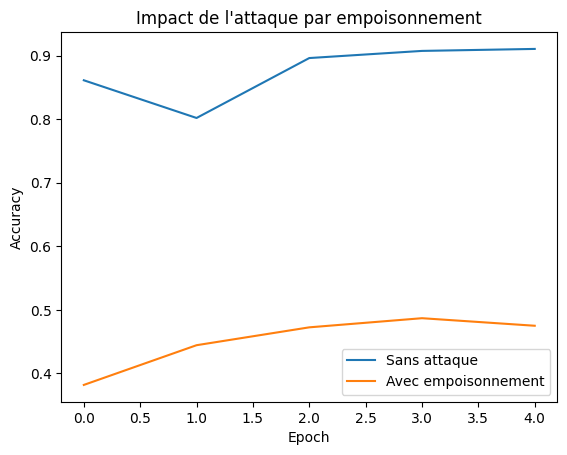

In [20]:
plt.plot(history.history['val_accuracy'],         label='Sans attaque')
plt.plot(history_poisoned.history['val_accuracy'], label='Avec empoisonnement')
plt.title("Impact de l'attaque par empoisonnement")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 11. Test du modèle empoisonné

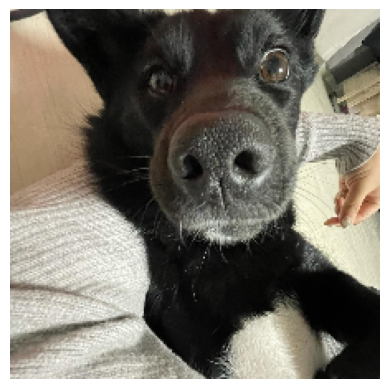

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Animal prédit : bird avec une probabilité de : 37.22%


In [21]:
# Test sur la même image qu'en section 7
new_image  = load_image(image_path)
prediction = model_poisoned.predict(new_image)
label, probabilite = get_label_probabilite(prediction)
print(f"Animal prédit : {label} avec une probabilité de : {probabilite*100:.2f}%")

# 12. Sauvegarde des modèles

In [22]:
model.save('/content/saved_models/efficientnet_clean_final.keras')
model_poisoned.save('/content/saved_models/efficientnet_poisoned_final.keras')

print("Modèles sauvegardés :")
for f in sorted(os.listdir('/content/saved_models')):
    size = os.path.getsize(f'/content/saved_models/{f}') / 1024**2
    print(f"  {f:<50}  ({size:.1f} MB)")

Modèles sauvegardés :
  efficientnet_clean_final.keras                      (49.0 MB)
  efficientnet_poisoned_final.keras                   (49.0 MB)


# 13. Conclusion

- Une simple modification des labels peut fortement dégrader un modèle
- La performance n'est pas toujours un indicateur de fiabilité
- La sécurité des données est un enjeu majeur en IA

Ce type d'attaque peut être utilisé pour :
- sabotage de systèmes IA
- manipulation de décisions automatiques